In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
#Create Dataset
np.random.seed(42)

n = 150

df = pd.DataFrame({
    "Gender": np.random.choice(["Male", "Female"], n, p=[0.7, 0.3]),
    "Married": np.random.choice(["Yes", "No"], n, p=[0.6, 0.4]),
    "Education": np.random.choice(["Graduate", "Not Graduate"], n, p=[0.7, 0.3]),
    "ApplicantIncome": np.random.normal(8000, 3000, n).astype(int),
    "LoanAmount": np.random.normal(200, 80, n).astype(int),
    "Credit_History": np.random.choice([0, 1], n, p=[0.3, 0.7])
})

df["ApplicantIncome"] = np.clip(df["ApplicantIncome"], 1500, 25000)
df["LoanAmount"] = np.clip(df["LoanAmount"], 50, 600)

score = (
    df["ApplicantIncome"]/10000 +
    df["Credit_History"]*0.5 +
    df["Education"].map({"Graduate":1, "Not Graduate":0})*0.2 +
    df["Married"].map({"Yes":1, "No":0})*0.1
)

noise = np.random.normal(0, 0.2, n)

df["Loan_Status"] = ((score + noise) > 0.6).astype(int)

df.head()

,Gender,Married,Education,ApplicantIncome,LoanAmount,Credit_History,Loan_Status
0,Male,No,Graduate,8932,274,1,1
1,Female,Yes,Graduate,12426,352,1,1
2,Female,Yes,Graduate,10572,88,0,1
3,Male,Yes,Graduate,7520,245,1,1
4,Male,No,Not Graduate,7942,147,0,1


In [4]:
#Basic EDA
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df["Loan_Status"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           150 non-null    object
 1   Married          150 non-null    object
 2   Education        150 non-null    object
 3   ApplicantIncome  150 non-null    int64 
 4   LoanAmount       150 non-null    int64 
 5   Credit_History   150 non-null    int64 
 6   Loan_Status      150 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 8.3+ KB
None
       ApplicantIncome  LoanAmount  Credit_History  Loan_Status
count       150.000000  150.000000      150.000000   150.000000
mean       8071.700000  195.233333        0.600000     0.953333
std        3116.324926   77.110347        0.491539     0.211631
min        1500.000000   50.000000        0.000000     0.000000
25%        5703.250000  140.000000        0.000000     1.000000
50%        7960.000000  195.000000        1.000000  

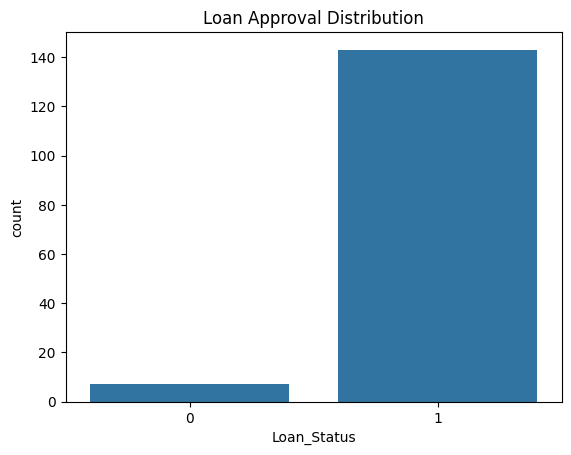

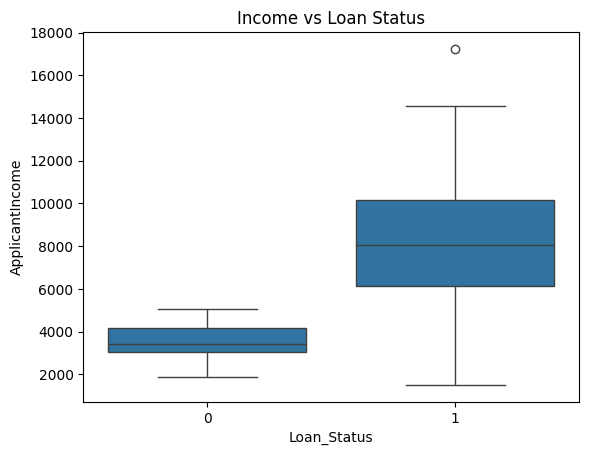

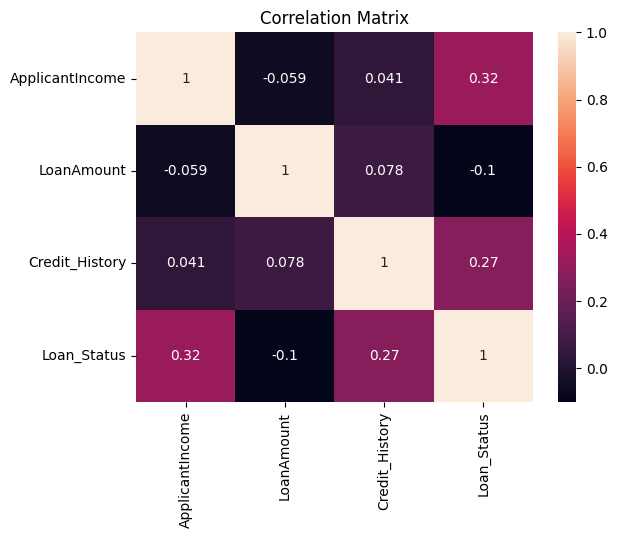

In [7]:
#Visualization
sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Approval Distribution")
plt.show()

sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=df)
plt.title("Income vs Loan Status")
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [8]:
#Data PreProcessing
le = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = le.fit_transform(df[col])

In [9]:
#Train-Test Split
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
#Algorithm
#Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_lr_train = lr.predict(X_train)
pred_lr_test = lr.predict(X_test)

In [13]:
#Decision Tree
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

pred_dt_train = dt.predict(X_train)
pred_dt_test = dt.predict(X_test)

In [14]:
#Accuracy
print("=== Logistic Regression ===")
print("Train Accuracy:", accuracy_score(y_train, pred_lr_train))
print("Test Accuracy:", accuracy_score(y_test, pred_lr_test))

print("\n=== Decision Tree ===")
print("Train Accuracy:", accuracy_score(y_train, pred_dt_train))
print("Test Accuracy:", accuracy_score(y_test, pred_dt_test))

=== Logistic Regression ===
Train Accuracy: 0.95
Test Accuracy: 1.0

=== Decision Tree ===
Train Accuracy: 1.0
Test Accuracy: 0.9666666666666667


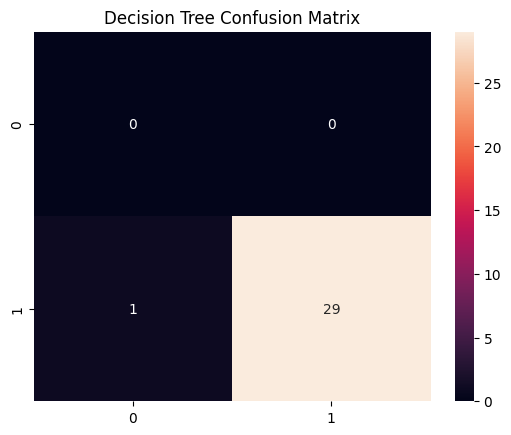

In [15]:
sns.heatmap(confusion_matrix(y_test, pred_dt_test), annot=True, fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [16]:
#Finalresults = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Train Accuracy": [
        accuracy_score(y_train, pred_lr_train),
        accuracy_score(y_train, pred_dt_train)
    ],
    "Test Accuracy": [
        accuracy_score(y_test, pred_lr_test),
        accuracy_score(y_test, pred_dt_test)
    ]
})

results

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.95,1.000000
1,Decision Tree,1.00,0.966667
